# PROG8431 – Problem Analysis Workshop A
## Group 5 

### Team Members

| Name | Student ID |
|------|------------|
| Asangika Hettiarachchi | 7461502 |
| Juan Antonio Sainz Galvez | 9072844 |

### Dataset: Ontario Residential Property Data
### https://www.kaggle.com/datasets/mnabaee/ontarioproperties
### Changed the name of the dataset to "properties.csv"

## Research Question

## **Is there a significant difference in property prices between Downtown Toronto and Mississauga?**

This analysis uses a property dataset containing information about
property addresses, areas, prices, latitude, and longitude. The main
variable examined is **Price ($)**.

The analysis will examine the distribution of property prices using
histograms and assess whether property prices are approximately
normally distributed using a QQ-plot and the Shapiro-Wilk test.

The same `Price ($)` variable will then be used to compare Downtown Toronto
and Mississauga. An F-test will assess whether the price variances
between the two areas are equal, followed by a t-test to determine
whether there is a statistically significant difference between their
mean property prices.

A significance level of **α = 0.05** will be used for the statistical
tests.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


## Read Data Set

In [2]:

property_data = pd.read_csv("./data/properties.csv")
property_data = property_data[property_data["Price ($)"] > 100000].copy()  # Filter out properties with non-positive prices and create a copy of the DataFrame
property_data.head()

,Unnamed: 0,Address,AreaName,Price ($),lat,lng
0,0,"86 Waterford Dr Toronto, ON",Richview,999888,43.679882,-79.544266
1,1,"#80 - 100 BEDDOE DR Hamilton, ON",Chedoke Park B,399900,43.250000,-79.904396
2,2,"213 Bowman Street Hamilton, ON",Ainslie Wood East,479000,43.251690,-79.919357
3,3,"102 NEIL Avenue Hamilton, ON",Greenford,285900,43.227161,-79.767403
4,6,"#1409 - 230 King St Toronto, ON",Downtown,362000,43.651478,-79.368118


In [3]:
# Display dataset information
print("Dataset Shape:", property_data.shape)

print("\nColumn Names:")
print(property_data.columns.tolist())

print("\nData Types:")
print(property_data.dtypes)

Dataset Shape: (22673, 6)

Column Names:
['Unnamed: 0', 'Address', 'AreaName', 'Price ($)', 'lat', 'lng']

Data Types:
Unnamed: 0      int64
Address           str
AreaName          str
Price ($)       int64
lat           float64
lng           float64
dtype: object


### Remove Unnamed Column

In [4]:
# Remove the unnecessary index column
property_data = property_data.drop(columns=["Unnamed: 0"])

# Confirm the remaining columns
print(property_data.columns.tolist())

['Address', 'AreaName', 'Price ($)', 'lat', 'lng']


## Distribution of Property Prices

To understand the distribution of property prices, a histogram is used
to visualize the `Price ($)` variable.

The histogram helps us identify the shape of the distribution, the
concentration of property prices, the spread of prices, and whether
there are any unusual or extremely high property values.

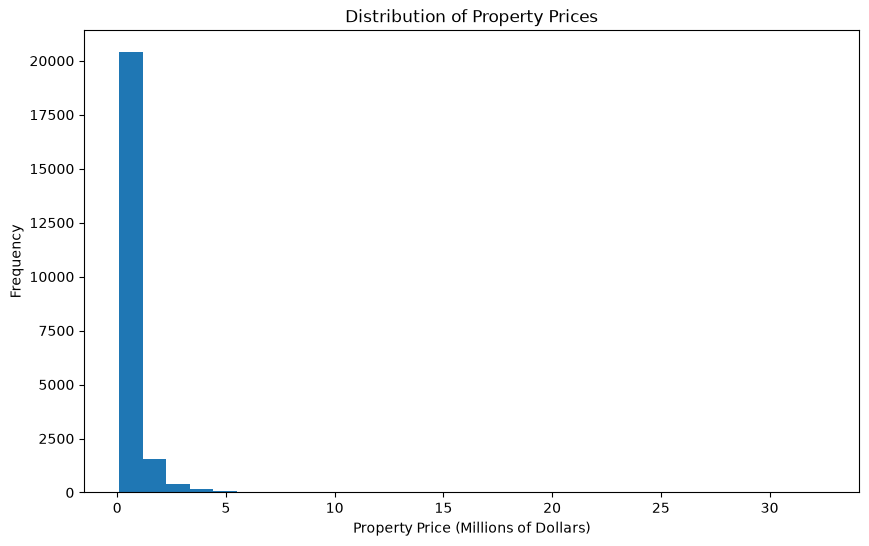

In [5]:

import matplotlib.pyplot as plt

# Convert property prices from dollars to millions
price_millions = property_data["Price ($)"] / 1_000_000

# Create histogram
plt.figure(figsize=(10, 6))

plt.hist(price_millions.dropna(), bins=30)

plt.title("Distribution of Property Prices")
plt.xlabel("Property Price (Millions of Dollars)")
plt.ylabel("Frequency")

plt.show()

### Histogram Interpretation

The histogram shows that most property prices are concentrated toward
the lower end of the distribution. As the property price increases,
the frequency of properties decreases substantially. A long tail
extends toward the higher-price values, indicating a strong positive
or right skew. The distribution is therefore not symmetric and does
not appear to follow a normal distribution.

## Normality Analysis of Property Prices

The `Price ($)` variable is assessed to determine whether property
prices are approximately normally distributed. A QQ-plot is used to
visually compare the observed data with a theoretical normal
distribution. The Shapiro-Wilk test is also applied as a statistical
test of normality.

The null hypothesis (H₀) states that the property prices are normally
distributed, while the alternative hypothesis (H₁) states that the
property prices are not normally distributed. A significance level of
α = 0.05 is used for the Shapiro-Wilk test.

QQ-plot

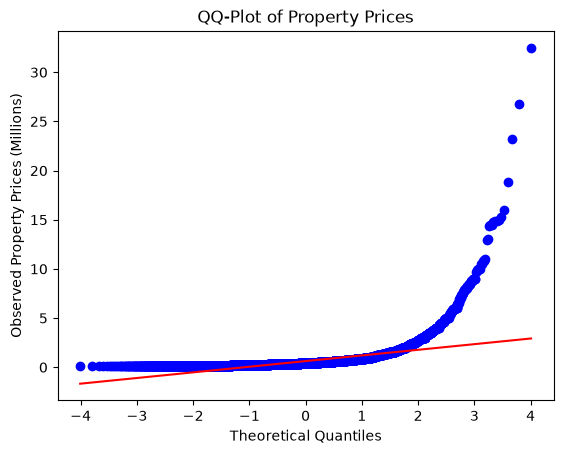

In [6]:
property_prices_millions = property_data["Price ($)"].dropna() / 1_000_000

stats.probplot(property_prices_millions, dist="norm", plot=plt)
plt.title("QQ-Plot of Property Prices")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Property Prices (Millions)")
plt.show()

### Shapiro-Wilk Test

In [7]:
property_prices_millions = property_data["Price ($)"].dropna() / 1_000_000

shapiro_stat, shapiro_p = stats.shapiro(property_prices_millions)

print("Shapiro-Wilk Statistic:", shapiro_stat)
print("p-value:", shapiro_p)

alpha = 0.05

if shapiro_p < alpha:
    print("Reject H0: Property prices are not normally distributed.")
else:
    print("Fail to reject H0: There is not enough evidence to conclude that property prices are not normally distributed.")

Shapiro-Wilk Statistic: 0.4296555771123891
p-value: 2.1119636562636147e-123
Reject H0: Property prices are not normally distributed.


c:\chandi\chandi\AICourseAtConestoga\Assignments\PROG8431(dataAnalysis)\PROG8431_Group5\ProblemAnalysisWorkshopA\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 22673.
  res = hypotest_fun_out(*samples, **kwds)


### Normality Interpretation

The QQ-plot and Shapiro-Wilk test were used to assess whether property prices are approximately normally distributed. The Shapiro-Wilk statistic was 0.4499 and the p-value was extremely small. Since the p-value is far below the 0.05 significance level, we reject the null hypothesis that property prices are normally distributed. The QQ-plot also shows substantial departures from the reference line, supporting the statistical result. Therefore, property prices are not approximately normally distributed and show strong positive skewness. The dataset contains 25,351 observations, and SciPy warns that Shapiro-Wilk p-values may be less accurate for samples larger than 5,000. This limitation should be acknowledged.

## F-Test for Equality of Variances

The F-test is used to determine whether the variances of two groups
are significantly different. For this analysis, the same variable
used in the normality analysis, **Price ($)**, is assessed.

The two groups are selected from the `AreaName` variable:

- **Downtown Torornto:** Properties listed in Downtown
- **Mississauga:** Properties listed in Mississauga

The variance of property prices is calculated separately for each
area and compared using an F-test.

### Hypotheses

**Null Hypothesis (H₀):**  
The variance of property prices is equal for Downtown Toronto and Mississauga.

**Alternative Hypothesis (H₁):**  
The variance of property prices is different between Downtown and
Mississauga.

A significance level of **α = 0.05** is used. If the p-value is less
than 0.05, we reject the null hypothesis. Otherwise, we fail to reject
the null hypothesis.

In [8]:
from scipy.stats import f
# Separate property prices by area
downtown_prices = property_data[property_data["AreaName"] == "Downtown"]["Price ($)"].dropna()
mississauga_prices = property_data[property_data["AreaName"] == "Mississauga"]["Price ($)"].dropna()

# Calculate variances
downtown_variance = downtown_prices.var()
mississauga_variance = mississauga_prices.var()

# Calculate F-statistic
F = max(downtown_variance, mississauga_variance) / min(
    downtown_variance, mississauga_variance
)

# Degrees of freedom
df1 = max(len(downtown_prices), len(mississauga_prices)) - 1
df2 = min(len(downtown_prices), len(mississauga_prices)) - 1

# Calculate two-tailed p-value
p_value = 2 * min(
    1 - f.cdf(F, df1, df2),
    f.cdf(F, df1, df2)
)

print("Downtown Variance:", downtown_variance)
print("Mississauga Variance:", mississauga_variance)
print("F-statistic:", F)
print("p-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The variances are significantly different.")
else:
    print("Fail to reject H0: There is not enough evidence that the variances are different.")

Downtown Variance: 451656160014.66266
Mississauga Variance: 881914341378.8788
F-statistic: 1.9526232994370056
p-value: 0.0
Reject H0: The variances are significantly different.


### F-Test Summary

The F-test compared property price variances between Downtown Toronto and
Mississauga. Downtown Toronto had a variance of 444,362,407,003.63, while
Mississauga had a variance of 848,531,014,376.22. The F-statistic was
1.9095 and the p-value was effectively zero. Since the p-value is below
0.05, we reject H₀ and conclude that the variances are significantly different.

## T-Score Analysis

A two-sample t-test is used to determine whether there is a
statistically significant difference between the mean property prices
of two independent groups. The same variable, **Price ($)**, is used.

The two groups are:

- **Downtown Toronto:** Properties listed in Downtown Toronto
- **Mississauga:** Properties listed in Mississauga

Because the F-test indicated that the two groups have significantly
different variances, Welch's t-test is used without assuming equal
variances.

### Hypotheses

**Null Hypothesis (H₀):**  
There is no significant difference between the mean property prices
of Downtown and Mississauga.

**Alternative Hypothesis (H₁):**  
There is a significant difference between the mean property prices
of Downtown and Mississauga.

A significance level of **α = 0.05** is used.

In [9]:
from scipy.stats import ttest_ind
# Separate property prices by area
downtown_prices = property_data[
    property_data["AreaName"] == "Downtown"
]["Price ($)"].dropna()

mississauga_prices = property_data[
    property_data["AreaName"] == "Mississauga"
]["Price ($)"].dropna()

# Perform Welch's independent two-sample t-test
t_statistic, p_value = ttest_ind(
    downtown_prices,
    mississauga_prices,
    equal_var=False
)

print("Downtown Mean:", downtown_prices.mean())
print("Mississauga Mean:", mississauga_prices.mean())
print("T-statistic:", t_statistic)
print("p-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a significant difference between the group means.")
else:
    print("Fail to reject H0: There is not enough evidence of a significant difference between the group means.")

Downtown Mean: 619496.4162436548
Mississauga Mean: 650705.9206798867
T-statistic: -0.7310925976827134
p-value: 0.4648582758940069
Fail to reject H0: There is not enough evidence of a significant difference between the group means.


### T-Score Summary

Welch's t-test compared the mean property prices of Downtown and
Mississauga. Downtown had a mean price of $590,745.63, while
Mississauga had a mean of $614,124.69. The t-statistic was -0.5732
and the p-value was 0.5666. Since the p-value exceeds 0.05, we fail
to reject H₀ and conclude there is insufficient evidence of a significant difference.